In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (23486, 11)

Column Names:
['number', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

First 5 Rows:


,number,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   number                   23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB


In [2]:
df_work = df.copy()

df_work = df_work.drop(columns=["number"])

target_column = "Recommended IND"
text_columns = ["Title", "Review Text"]

categorical_columns = [
    "Division Name",
    "Department Name",
    "Class Name"
]

df_work["Clothing ID"] = df_work["Clothing ID"].astype(str)

for column in categorical_columns:
    df_work[column] = df_work[column].fillna("Unknown")

y = df_work[target_column].copy()

print("Dataset Shape After Removing Index Column:", df_work.shape)
print("\nTarget Distribution:")
print(y.value_counts())

print("\nMissing Values in Categorical Columns:")
print(df_work[categorical_columns].isnull().sum())

print("\nCategorical Column Data Types:")
print(df_work[categorical_columns + ["Clothing ID"]].dtypes)

Dataset Shape After Removing Index Column: (23486, 10)

Target Distribution:
Recommended IND
1    19314
0     4172
Name: count, dtype: int64

Missing Values in Categorical Columns:
Division Name      0
Department Name    0
Class Name         0
dtype: int64

Categorical Column Data Types:
Division Name      str
Department Name    str
Class Name         str
Clothing ID        str
dtype: object


,Column,Unique Categories,Unique Ratio,Selected Strategy
0,Division Name,4,0.000170,One-Hot Encoding
1,Department Name,7,0.000298,One-Hot Encoding
2,Class Name,21,0.000894,Rare Binning + One-Hot Encoding
3,Clothing ID,1206,0.051350,Target and Frequency Encoding


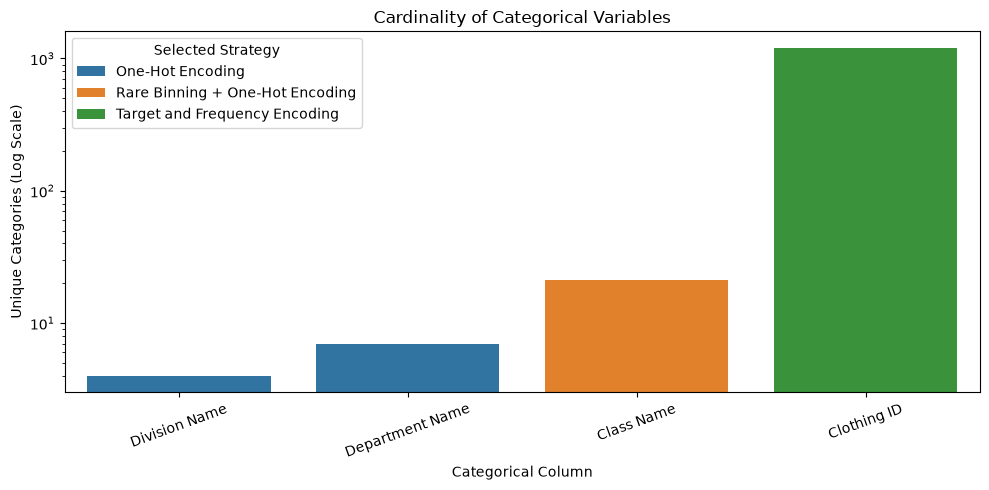

In [3]:
encoding_columns = [
    "Division Name",
    "Department Name",
    "Class Name",
    "Clothing ID"
]

cardinality_records = []

for column in encoding_columns:
    unique_count = df_work[column].nunique()
    unique_ratio = unique_count / len(df_work)

    if unique_count <= 10:
        strategy = "One-Hot Encoding"
    elif unique_count <= 30:
        strategy = "Rare Binning + One-Hot Encoding"
    else:
        strategy = "Target and Frequency Encoding"

    cardinality_records.append({
        "Column": column,
        "Unique Categories": unique_count,
        "Unique Ratio": unique_ratio,
        "Selected Strategy": strategy
    })

cardinality_report = pd.DataFrame(cardinality_records)

display(cardinality_report)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=cardinality_report,
    x="Column",
    y="Unique Categories",
    hue="Selected Strategy"
)

plt.yscale("log")
plt.title("Cardinality of Categorical Variables")
plt.xlabel("Categorical Column")
plt.ylabel("Unique Categories (Log Scale)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [4]:
class_column = "Class Name"

minimum_frequency = max(
    10,
    int(np.ceil(len(df_work) * 0.005))
)

class_frequencies = df_work[class_column].value_counts()

rare_classes = class_frequencies[
    (class_frequencies < minimum_frequency) &
    (class_frequencies.index != "Unknown")
].index.tolist()

df_work["Class Name Binned"] = df_work[class_column].where(
    ~df_work[class_column].isin(rare_classes),
    "Rare"
)

print("Minimum Frequency Threshold:", minimum_frequency)
print("Rare Categories:", rare_classes)

print("\nBefore Binning:")
print(df_work[class_column].value_counts())

print("\nAfter Binning:")
print(df_work["Class Name Binned"].value_counts())

print(
    "\nCategories Before:",
    df_work[class_column].nunique()
)

print(
    "Categories After:",
    df_work["Class Name Binned"].nunique()
)

Minimum Frequency Threshold: 118
Rare Categories: ['Casual bottoms', 'Chemises']

Before Binning:
Class Name
Dresses           6319
Knits             4843
Blouses           3097
Sweaters          1428
Pants             1388
Jeans             1147
Fine gauge        1100
Skirts             945
Jackets            704
Lounge             691
Swim               350
Outerwear          328
Shorts             317
Sleep              228
Legwear            165
Intimates          154
Layering           146
Trend              119
Unknown             14
Casual bottoms       2
Chemises             1
Name: count, dtype: int64

After Binning:
Class Name Binned
Dresses       6319
Knits         4843
Blouses       3097
Sweaters      1428
Pants         1388
Jeans         1147
Fine gauge    1100
Skirts         945
Jackets        704
Lounge         691
Swim           350
Outerwear      328
Shorts         317
Sleep          228
Legwear        165
Intimates      154
Layering       146
Trend          119
Unknow

In [5]:
from sklearn.preprocessing import OneHotEncoder

one_hot_columns = [
    "Division Name",
    "Department Name",
    "Class Name Binned"
]

one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    dtype=np.int8
)

one_hot_array = one_hot_encoder.fit_transform(
    df_work[one_hot_columns]
)

one_hot_feature_names = one_hot_encoder.get_feature_names_out(
    one_hot_columns
)

df_one_hot = pd.DataFrame(
    one_hot_array,
    columns=one_hot_feature_names,
    index=df_work.index
)

print("Original Selected Columns:", len(one_hot_columns))
print("One-Hot Encoded Columns:", df_one_hot.shape[1])
print("Encoded Dataset Shape:", df_one_hot.shape)

print("\nGenerated Feature Names:")
print(df_one_hot.columns.tolist())

display(df_one_hot.head())

Original Selected Columns: 3
One-Hot Encoded Columns: 31
Encoded Dataset Shape: (23486, 31)

Generated Feature Names:
['Division Name_General', 'Division Name_General Petite', 'Division Name_Initmates', 'Division Name_Unknown', 'Department Name_Bottoms', 'Department Name_Dresses', 'Department Name_Intimate', 'Department Name_Jackets', 'Department Name_Tops', 'Department Name_Trend', 'Department Name_Unknown', 'Class Name Binned_Blouses', 'Class Name Binned_Dresses', 'Class Name Binned_Fine gauge', 'Class Name Binned_Intimates', 'Class Name Binned_Jackets', 'Class Name Binned_Jeans', 'Class Name Binned_Knits', 'Class Name Binned_Layering', 'Class Name Binned_Legwear', 'Class Name Binned_Lounge', 'Class Name Binned_Outerwear', 'Class Name Binned_Pants', 'Class Name Binned_Rare', 'Class Name Binned_Shorts', 'Class Name Binned_Skirts', 'Class Name Binned_Sleep', 'Class Name Binned_Sweaters', 'Class Name Binned_Swim', 'Class Name Binned_Trend', 'Class Name Binned_Unknown']


,Division Name_General,Division Name_General Petite,Division Name_Initmates,Division Name_Unknown,Department Name_Bottoms,Department Name_Dresses,Department Name_Intimate,Department Name_Jackets,Department Name_Tops,Department Name_Trend,...,Class Name Binned_Outerwear,Class Name Binned_Pants,Class Name Binned_Rare,Class Name Binned_Shorts,Class Name Binned_Skirts,Class Name Binned_Sleep,Class Name Binned_Sweaters,Class Name Binned_Swim,Class Name Binned_Trend,Class Name Binned_Unknown
0,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
clothing_frequency_count = df_work["Clothing ID"].value_counts()

clothing_frequency_ratio = df_work[
    "Clothing ID"
].value_counts(normalize=True)

df_work["Clothing ID Frequency"] = df_work[
    "Clothing ID"
].map(clothing_frequency_ratio)

frequency_mapping = pd.DataFrame({
    "Clothing ID": clothing_frequency_count.index,
    "Record Count": clothing_frequency_count.values,
    "Frequency Ratio": clothing_frequency_ratio.reindex(
        clothing_frequency_count.index
    ).values
})

frequency_mapping = frequency_mapping.sort_values(
    by="Record Count",
    ascending=False
).reset_index(drop=True)

print("Unique Clothing IDs:", df_work["Clothing ID"].nunique())
print("Generated Frequency Features: 1")

print("\nFrequency Feature Statistics:")
print(df_work["Clothing ID Frequency"].describe())

display(frequency_mapping.head(10))

display(
    df_work[
        ["Clothing ID", "Clothing ID Frequency"]
    ].head()
)

Unique Clothing IDs: 1206
Generated Frequency Features: 1

Frequency Feature Statistics:
count    23486.000000
mean         0.011233
std          0.011457
min          0.000043
25%          0.002470
50%          0.007451
75%          0.015243
max          0.043600
Name: Clothing ID Frequency, dtype: float64


,Clothing ID,Record Count,Frequency Ratio
0,1078,1024,0.043600
1,862,806,0.034318
2,1094,756,0.032189
3,1081,582,0.024781
4,872,545,0.023205
5,829,527,0.022439
6,1110,480,0.020438
7,868,430,0.018309
8,895,404,0.017202
9,936,358,0.015243


,Clothing ID,Clothing ID Frequency
0,767,0.000085
1,1080,0.012305
2,1077,0.012646
3,1049,0.001363
4,847,0.000170


In [7]:
from sklearn.model_selection import StratifiedKFold

category_column = "Clothing ID"
smoothing_strength = 20

target_encoded_values = pd.Series(
    index=df_work.index,
    dtype="float64"
)

stratified_folds = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for train_index, validation_index in stratified_folds.split(
    df_work,
    y
):
    training_categories = df_work.loc[
        train_index,
        category_column
    ]

    training_target = y.loc[train_index]

    validation_categories = df_work.loc[
        validation_index,
        category_column
    ]

    fold_global_mean = training_target.mean()

    fold_statistics = pd.DataFrame({
        category_column: training_categories,
        "Target": training_target
    }).groupby(category_column)["Target"].agg(
        ["mean", "count"]
    )

    fold_statistics["Smoothed Target"] = (
        fold_statistics["count"] * fold_statistics["mean"] +
        smoothing_strength * fold_global_mean
    ) / (
        fold_statistics["count"] + smoothing_strength
    )

    target_encoded_values.loc[validation_index] = (
        validation_categories
        .map(fold_statistics["Smoothed Target"])
        .fillna(fold_global_mean)
    )

df_work["Clothing ID Target Encoded"] = target_encoded_values

global_target_mean = y.mean()

final_target_statistics = df_work.groupby(
    category_column
)[target_column].agg(["mean", "count"])

final_target_statistics["Smoothed Target"] = (
    final_target_statistics["count"] *
    final_target_statistics["mean"] +
    smoothing_strength * global_target_mean
) / (
    final_target_statistics["count"] +
    smoothing_strength
)

target_encoding_mapping = (
    final_target_statistics
    .sort_values("count", ascending=False)
    .reset_index()
)

print("Global Recommendation Rate:", round(global_target_mean, 4))
print(
    "Missing Encoded Values:",
    df_work["Clothing ID Target Encoded"].isnull().sum()
)

print("\nTarget-Encoded Feature Statistics:")
print(df_work["Clothing ID Target Encoded"].describe())

display(target_encoding_mapping.head(10))

display(
    df_work[
        [
            "Clothing ID",
            "Recommended IND",
            "Clothing ID Target Encoded"
        ]
    ].head(10)
)

Global Recommendation Rate: 0.8224
Missing Encoded Values: 0

Target-Encoded Feature Statistics:
count    23486.000000
mean         0.823105
std          0.043367
min          0.623140
25%          0.802774
50%          0.823743
75%          0.847925
max          0.938739
Name: Clothing ID Target Encoded, dtype: float64


,Clothing ID,mean,count,Smoothed Target
0,1078,0.821289,1024,0.821310
1,862,0.820099,806,0.820154
2,1094,0.821429,756,0.821453
3,1081,0.848797,582,0.847919
4,872,0.877064,545,0.875128
5,829,0.827324,527,0.827143
6,1110,0.839583,480,0.838894
7,868,0.755814,430,0.758772
8,895,0.844059,404,0.843036
9,936,0.821229,358,0.821289


,Clothing ID,Recommended IND,Clothing ID Target Encoded
0,767,1,0.830803
1,1080,1,0.841787
2,1077,0,0.811814
3,1049,1,0.863476
4,847,1,0.783184
5,1080,0,0.827720
6,858,1,0.706887
7,858,1,0.714804
8,1077,1,0.787965
9,1077,1,0.797035


In [8]:
from sklearn.decomposition import TruncatedSVD

clothing_one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype=np.float32
)

clothing_one_hot_sparse = clothing_one_hot_encoder.fit_transform(
    df_work[["Clothing ID"]]
)

number_of_components = min(
    20,
    clothing_one_hot_sparse.shape[1] - 1
)

svd_model = TruncatedSVD(
    n_components=number_of_components,
    random_state=42
)

clothing_svd_array = svd_model.fit_transform(
    clothing_one_hot_sparse
)

svd_feature_names = [
    f"Clothing ID SVD Component {number}"
    for number in range(1, number_of_components + 1)
]

df_clothing_svd = pd.DataFrame(
    clothing_svd_array,
    columns=svd_feature_names,
    index=df_work.index
)

explained_variance = svd_model.explained_variance_ratio_.sum()

original_clothing_features = (
    clothing_one_hot_sparse.shape[1]
)

print(
    "Clothing ID One-Hot Features:",
    original_clothing_features
)

print(
    "Features After Truncated SVD:",
    df_clothing_svd.shape[1]
)

print(
    "Feature Reduction:",
    original_clothing_features -
    df_clothing_svd.shape[1]
)

print(
    "Total Explained Variance:",
    round(explained_variance, 4)
)

display(df_clothing_svd.head())

Clothing ID One-Hot Features: 1206
Features After Truncated SVD: 20
Feature Reduction: 1186
Total Explained Variance: 0.3756


,Clothing ID SVD Component 1,Clothing ID SVD Component 2,Clothing ID SVD Component 3,Clothing ID SVD Component 4,Clothing ID SVD Component 5,Clothing ID SVD Component 6,Clothing ID SVD Component 7,Clothing ID SVD Component 8,Clothing ID SVD Component 9,Clothing ID SVD Component 10,Clothing ID SVD Component 11,Clothing ID SVD Component 12,Clothing ID SVD Component 13,Clothing ID SVD Component 14,Clothing ID SVD Component 15,Clothing ID SVD Component 16,Clothing ID SVD Component 17,Clothing ID SVD Component 18,Clothing ID SVD Component 19,Clothing ID SVD Component 20
0,-1.171209e-09,1.572463e-09,-3.126556e-09,-1.941885e-09,1.998191e-10,-4.459255e-10,1.328668e-09,-9.003965e-10,-2.287761e-09,-4.700547e-10,-2.761183e-09,-3.376180e-09,-1.352549e-10,9.003362e-09,-8.341978e-09,7.139251e-10,-4.433561e-09,1.317361e-08,-6.370587e-10,7.708067e-09
1,-1.007772e-05,-7.550817e-06,5.374993e-06,-1.628428e-04,2.785183e-05,5.097628e-05,-4.101390e-04,9.765567e-04,3.811990e-03,-9.744836e-04,6.327462e-03,4.991124e-03,-3.295003e-03,1.939264e-02,7.014715e-02,5.432033e-02,-2.893168e-01,8.953176e-01,-3.125447e-01,-1.118297e-02
2,1.453996e-05,-1.644485e-05,5.958817e-06,2.303445e-04,-5.437940e-05,-1.010810e-04,5.560846e-04,-9.444231e-04,-4.177290e-03,-1.492972e-03,-8.292026e-03,-1.036362e-02,-4.586857e-03,-9.182937e-02,9.795493e-01,5.926438e-02,8.910540e-02,-8.041637e-03,1.008806e-01,-8.986051e-03
3,-4.967187e-10,8.199134e-10,-2.019145e-09,-9.958327e-10,6.889818e-09,1.838385e-09,2.031425e-09,-9.055868e-08,5.929488e-09,-4.688068e-08,7.152712e-08,4.263946e-09,5.058333e-07,-3.288835e-07,2.275126e-07,1.873872e-07,8.136574e-07,6.877661e-07,-7.021958e-08,-6.960518e-07
4,2.503356e-10,-7.487376e-10,-2.212123e-09,-1.887600e-08,-2.779388e-08,-2.564470e-09,1.538102e-08,-1.324344e-08,-4.250727e-09,-1.091147e-09,2.123346e-09,1.252710e-08,1.621275e-08,-2.039510e-09,8.895774e-09,1.067485e-08,-1.357524e-08,-1.004127e-08,-3.260187e-09,-2.440393e-08


In [9]:
clothing_feature_names = (
    clothing_one_hot_encoder
    .get_feature_names_out(["Clothing ID"])
)

component_records = []

for component_number in range(number_of_components):
    component_weights = svd_model.components_[component_number]

    top_positions = np.argsort(
        np.abs(component_weights)
    )[-5:][::-1]

    for rank, position in enumerate(top_positions, start=1):
        component_records.append({
            "Component": component_number + 1,
            "Rank": rank,
            "Clothing Feature": clothing_feature_names[position],
            "Loading": component_weights[position]
        })

svd_component_report = pd.DataFrame(component_records)

display(svd_component_report.head(20))

,Component,Rank,Clothing Feature,Loading
0,1,1,Clothing ID_1078,1.000000
1,1,2,Clothing ID_1092,0.000051
2,1,3,Clothing ID_861,-0.000034
3,1,4,Clothing ID_1072,-0.000034
4,1,5,Clothing ID_873,-0.000033
5,2,1,Clothing ID_862,1.000000
6,2,2,Clothing ID_984,0.000089
7,2,3,Clothing ID_1008,0.000088
8,2,4,Clothing ID_873,0.000081
9,2,5,Clothing ID_1056,-0.000075


In [10]:
encoding_comparison = pd.DataFrame({
    "Technique": [
        "Direct Clothing ID One-Hot",
        "Frequency Encoding",
        "Target Encoding",
        "Truncated SVD"
    ],
    "Generated Features": [
        original_clothing_features,
        1,
        1,
        number_of_components
    ],
    "Interpretability": [
        "High but excessive",
        "High",
        "High",
        "Medium"
    ],
    "Feature Explosion Risk": [
        "Very High",
        "Very Low",
        "Very Low",
        "Low"
    ],
    "Selected for Final Dataset": [
        "No",
        "Yes",
        "Yes",
        "No"
    ]
})

display(encoding_comparison)

,Technique,Generated Features,Interpretability,Feature Explosion Risk,Selected for Final Dataset
0,Direct Clothing ID One-Hot,1206,High but excessive,Very High,No
1,Frequency Encoding,1,High,Very Low,Yes
2,Target Encoding,1,High,Very Low,Yes
3,Truncated SVD,20,Medium,Low,No


In [11]:
numerical_columns = [
    "Age",
    "Rating",
    "Positive Feedback Count"
]

high_cardinality_features = df_work[
    [
        "Clothing ID Frequency",
        "Clothing ID Target Encoded"
    ]
].copy()

final_features = pd.concat(
    [
        df_work[numerical_columns],
        high_cardinality_features,
        df_one_hot
    ],
    axis=1
)

final_encoded_dataset = pd.concat(
    [
        final_features,
        y.rename(target_column)
    ],
    axis=1
)

print("Original Dataset Shape:", df.shape)
print("Final Feature Matrix Shape:", final_features.shape)
print("Final Dataset Shape:", final_encoded_dataset.shape)

print(
    "\nObject Columns Remaining:",
    final_encoded_dataset.select_dtypes(
        include=["object", "string"]
    ).columns.tolist()
)

print(
    "Total Missing Values:",
    final_encoded_dataset.isnull().sum().sum()
)

print(
    "Duplicate Feature Names:",
    final_encoded_dataset.columns.duplicated().sum()
)

display(final_encoded_dataset.head())

Original Dataset Shape: (23486, 11)
Final Feature Matrix Shape: (23486, 36)
Final Dataset Shape: (23486, 37)

Object Columns Remaining: []
Total Missing Values: 0
Duplicate Feature Names: 0


,Age,Rating,Positive Feedback Count,Clothing ID Frequency,Clothing ID Target Encoded,Division Name_General,Division Name_General Petite,Division Name_Initmates,Division Name_Unknown,Department Name_Bottoms,...,Class Name Binned_Pants,Class Name Binned_Rare,Class Name Binned_Shorts,Class Name Binned_Skirts,Class Name Binned_Sleep,Class Name Binned_Sweaters,Class Name Binned_Swim,Class Name Binned_Trend,Class Name Binned_Unknown,Recommended IND
0,33,4,0,0.000085,0.830803,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1,34,5,4,0.012305,0.841787,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,60,3,0,0.012646,0.811814,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,50,5,0,0.001363,0.863476,0,1,0,0,1,...,1,0,0,0,0,0,0,0,0,1
4,47,5,6,0.000170,0.783184,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [12]:
rare_category_report = pd.DataFrame({
    "Original Category": rare_classes,
    "Original Frequency": [
        class_frequencies[category]
        for category in rare_classes
    ],
    "New Category": "Rare"
})

one_hot_feature_report = pd.DataFrame({
    "Generated Feature": df_one_hot.columns
})

validation_report = pd.DataFrame({
    "Validation Check": [
        "Original Rows",
        "Final Rows",
        "Original Columns",
        "Final Model Features",
        "Final Columns Including Target",
        "Missing Values",
        "Non-Numeric Features",
        "Duplicate Feature Names",
        "Original Clothing ID Categories",
        "SVD Components Tested"
    ],
    "Result": [
        len(df),
        len(final_encoded_dataset),
        df.shape[1],
        final_features.shape[1],
        final_encoded_dataset.shape[1],
        final_encoded_dataset.isnull().sum().sum(),
        len(
            final_encoded_dataset.select_dtypes(
                include=["object", "string"]
            ).columns
        ),
        final_encoded_dataset.columns.duplicated().sum(),
        original_clothing_features,
        number_of_components
    ]
})

display(validation_report)

,Validation Check,Result
0,Original Rows,23486
1,Final Rows,23486
2,Original Columns,11
3,Final Model Features,36
4,Final Columns Including Target,37
5,Missing Values,0
6,Non-Numeric Features,0
7,Duplicate Feature Names,0
8,Original Clothing ID Categories,1206
9,SVD Components Tested,20


In [13]:
final_encoded_dataset.to_csv(
    "womens_clothing_encoded_dataset.csv",
    index=False
)

cardinality_report.to_csv(
    "categorical_cardinality_report.csv",
    index=False
)

encoding_comparison.to_csv(
    "encoding_technique_comparison.csv",
    index=False
)

rare_category_report.to_csv(
    "rare_category_binning_report.csv",
    index=False
)

frequency_mapping.to_csv(
    "clothing_id_frequency_mapping.csv",
    index=False
)

target_encoding_mapping.to_csv(
    "clothing_id_target_encoding_mapping.csv",
    index=False
)

one_hot_feature_report.to_csv(
    "one_hot_feature_report.csv",
    index=False
)

svd_component_report.to_csv(
    "svd_component_interpretation.csv",
    index=False
)

validation_report.to_csv(
    "encoding_validation_report.csv",
    index=False
)

print("All files exported successfully.")

All files exported successfully.
